In [57]:

# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Libraries imported successfully.")

Libraries imported successfully.


In [58]:

# Load Datasets

sentiment_df = pd.read_csv("fear_greed_index.csv")
trader_df = pd.read_csv("historical_data.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [59]:

# Data Inspection


def inspect_data(df, name):
    print("="*60)
    print(f"{name}")
    print("="*60)

    print("\nShape")
    print(df.shape)

    print("\nColumns")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nMemory Usage")
    print(df.memory_usage(deep=True))

    print("\nFirst Five Rows")
    display(df.head())


inspect_data(sentiment_df, "Fear & Greed Dataset")
inspect_data(trader_df, "Historical Trader Dataset")

Fear & Greed Dataset

Shape
(2644, 4)

Columns
['timestamp', 'value', 'classification', 'date']

Data Types
timestamp          int64
value              int64
classification    object
date              object
dtype: object

Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows
0

Memory Usage
Index                132
timestamp          21152
value              21152
classification    148951
date              155996
dtype: int64

First Five Rows


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Historical Trader Dataset

Shape
(211224, 16)

Columns
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Data Types
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Or

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [60]:
print("Sentiment Duplicates:", sentiment_df.duplicated().sum())
print("Trader Duplicates:", trader_df.duplicated().sum())

Sentiment Duplicates: 0
Trader Duplicates: 0


In [ ]:

# Create Backup Copies

sentiment = sentiment_df.copy()
trader = trader_df.copy()

In [ ]:

# Remove Duplicate Rows

print("Sentiment duplicates before:", sentiment.duplicated().sum())
print("Trader duplicates before:", trader.duplicated().sum())

sentiment.drop_duplicates(inplace=True)
trader.drop_duplicates(inplace=True)

print("\nDuplicates after cleaning")

print("Sentiment:", sentiment.duplicated().sum())
print("Trader:", trader.duplicated().sum())

Sentiment duplicates before: 0
Trader duplicates before: 0

Duplicates after cleaning
Sentiment: 0
Trader: 0


In [ ]:

# Convert Date Columns

# Fear & Greed dataset
sentiment["date"] = pd.to_datetime(sentiment["date"])

# Trader dataset
trader["Timestamp IST"] = pd.to_datetime(
    trader["Timestamp IST"],
    dayfirst=True
)

trader["date"] = trader["Timestamp IST"].dt.normalize()

In [64]:
print(sentiment.info())

print()

print(trader.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side 

In [ ]:

# Standardize Text Columns

sentiment["classification"] = sentiment["classification"].str.strip()

trader["Side"] = trader["Side"].str.upper().str.strip()

trader["Direction"] = trader["Direction"].str.capitalize().str.strip()

In [66]:
print("Sentiment Missing Values")
print(sentiment.isnull().sum())

print()

print("Trader Missing Values")
print(trader.isnull().sum())

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64


In [67]:
print(sentiment["date"].dtype)
print(trader["date"].dtype)

datetime64[ns]
datetime64[ns]


In [ ]:

# Daily Performance Metrics

daily_performance = (
    trader.groupby("date")
    .agg(
        Total_PnL=("Closed PnL", "sum"),
        Average_PnL=("Closed PnL", "mean"),
        Total_Trades=("Trade ID", "count"),
        Winning_Trades=("Closed PnL", lambda x: (x > 0).sum()),
        Losing_Trades=("Closed PnL", lambda x: (x < 0).sum()),
    )
    .reset_index()
)

# Calculate Win Rate
daily_performance["Win_Rate"] = (
    daily_performance["Winning_Trades"]
    / daily_performance["Total_Trades"]
) * 100

daily_performance.head()

,date,Total_PnL,Average_PnL,Total_Trades,Winning_Trades,Losing_Trades,Win_Rate
0,2023-05-01,0.000000,0.000000,3,0,0,0.000000
1,2023-12-05,0.000000,0.000000,9,0,0,0.000000
2,2023-12-14,-205.434737,-18.675885,11,4,2,36.363636
3,2023-12-15,-24.632034,-12.316017,2,0,2,0.000000
4,2023-12-16,0.000000,0.000000,3,0,0,0.000000


In [ ]:

# Merge Daily Performance with Sentiment

analysis_df = pd.merge(
    daily_performance,
    sentiment[["date", "classification"]],
    on="date",
    how="inner"
)

analysis_df.head()

,date,Total_PnL,Average_PnL,Total_Trades,Winning_Trades,Losing_Trades,Win_Rate,classification
0,2023-05-01,0.000000,0.000000,3,0,0,0.000000,Greed
1,2023-12-05,0.000000,0.000000,9,0,0,0.000000,Extreme Greed
2,2023-12-14,-205.434737,-18.675885,11,4,2,36.363636,Greed
3,2023-12-15,-24.632034,-12.316017,2,0,2,0.000000,Greed
4,2023-12-16,0.000000,0.000000,3,0,0,0.000000,Greed


In [ ]:

# Performance Comparison

performance_summary = (
    analysis_df
    .groupby("classification")
    .agg({
        "Total_PnL": "mean",
        "Average_PnL": "mean",
        "Win_Rate": "mean",
        "Total_Trades": "mean"
    })
    .round(2)
)

performance_summary

,Total_PnL,Average_PnL,Win_Rate,Total_Trades
classification,,,,
Extreme Fear,52793.59,38.43,32.73,1528.57
Extreme Greed,23817.29,56.74,46.74,350.81
Fear,36891.82,31.28,32.91,679.53
Greed,11140.57,39.41,33.60,260.64
Neutral,19297.32,63.82,33.19,562.48


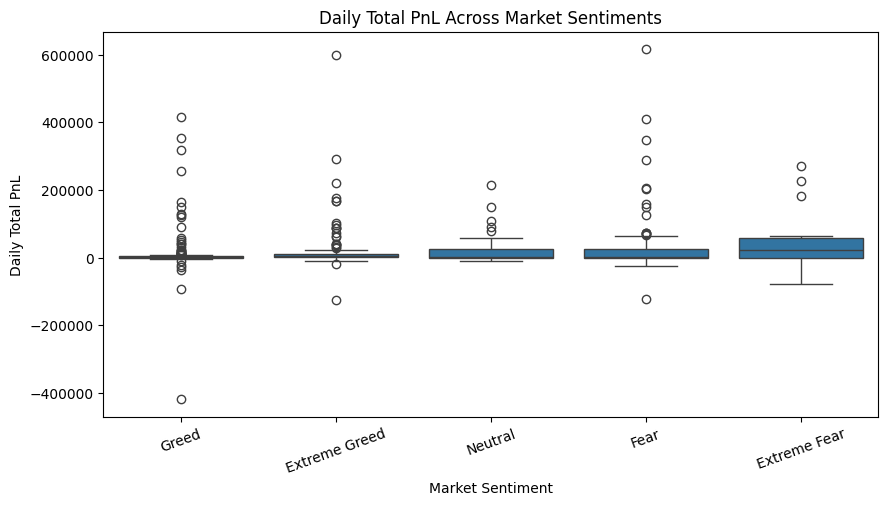

In [71]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=analysis_df,
    x="classification",
    y="Total_PnL"
)

plt.title("Daily Total PnL Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily Total PnL")
plt.xticks(rotation=20)

plt.show()

Behavior based on market sentiment

In [ ]:

# Daily Behaviour Metrics

daily_behaviour = (
    trader.groupby("date")
    .agg(
        Total_Trades=("Trade ID", "count"),
        Average_Trade_Size=("Size USD", "mean"),
        Average_Fee=("Fee", "mean"),
        Average_Execution_Price=("Execution Price", "mean")
    )
    .reset_index()
)

daily_behaviour.head()

,date,Total_Trades,Average_Trade_Size,Average_Fee,Average_Execution_Price
0,2023-05-01,3,159.000000,0.000000,1898.133333
1,2023-12-05,9,5556.203333,1.389051,11038.300000
2,2023-12-14,11,10291.213636,2.572803,8031.868818
3,2023-12-15,2,5304.975000,1.326245,2.982000
4,2023-12-16,3,5116.256667,1.279063,0.384707


In [ ]:

# Long vs Short Count

direction_daily = (
    trader.groupby(["date", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

direction_daily.head()

Direction,date,Auto-deleveraging,Buy,Close long,Close short,Liquidated isolated short,Long > short,Open long,Open short,Sell,Settlement,Short > long,Spot dust conversion
0,2023-05-01,0,0,0,0,0,0,3,0,0,0,0,0
1,2023-12-05,0,0,0,0,0,0,7,2,0,0,0,0
2,2023-12-14,0,0,4,2,0,0,3,2,0,0,0,0
3,2023-12-15,0,0,0,2,0,0,0,0,0,0,0,0
4,2023-12-16,0,0,0,0,0,0,3,0,0,0,0,0


In [ ]:

# Merge Behaviour with Sentiment

behaviour_analysis = pd.merge(
    daily_behaviour,
    sentiment[["date", "classification"]],
    on="date",
    how="inner"
)

behaviour_analysis.head()

,date,Total_Trades,Average_Trade_Size,Average_Fee,Average_Execution_Price,classification
0,2023-05-01,3,159.000000,0.000000,1898.133333,Greed
1,2023-12-05,9,5556.203333,1.389051,11038.300000,Extreme Greed
2,2023-12-14,11,10291.213636,2.572803,8031.868818,Greed
3,2023-12-15,2,5304.975000,1.326245,2.982000,Greed
4,2023-12-16,3,5116.256667,1.279063,0.384707,Greed


In [75]:
behaviour_summary = (
    behaviour_analysis
    .groupby("classification")
    .agg({
        "Total_Trades": "mean",
        "Average_Trade_Size": "mean",
        "Average_Fee": "mean"
    })
    .round(2)
)

behaviour_summary

,Total_Trades,Average_Trade_Size,Average_Fee
classification,,,
Extreme Fear,1528.57,4091.80,0.94
Extreme Greed,350.81,4410.52,1.04
Fear,679.53,6524.29,2.21
Greed,260.64,6735.30,1.89
Neutral,562.48,7157.53,2.28


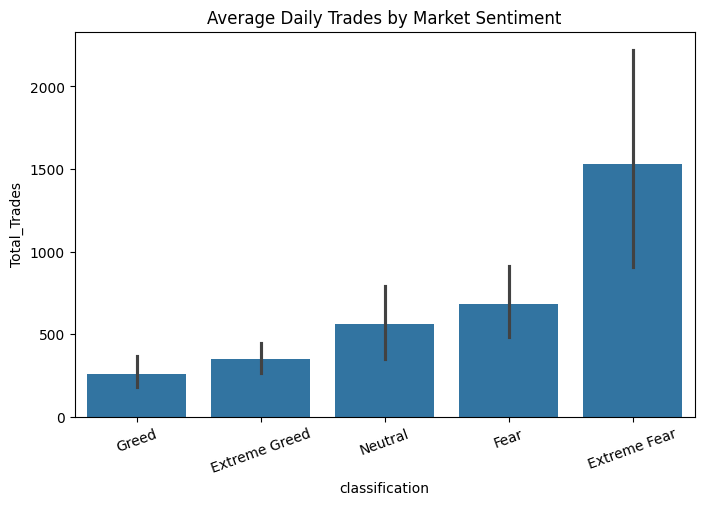

In [76]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=behaviour_analysis,
    x="classification",
    y="Total_Trades",
    estimator="mean"
)

plt.title("Average Daily Trades by Market Sentiment")
plt.xticks(rotation=20)
plt.show()

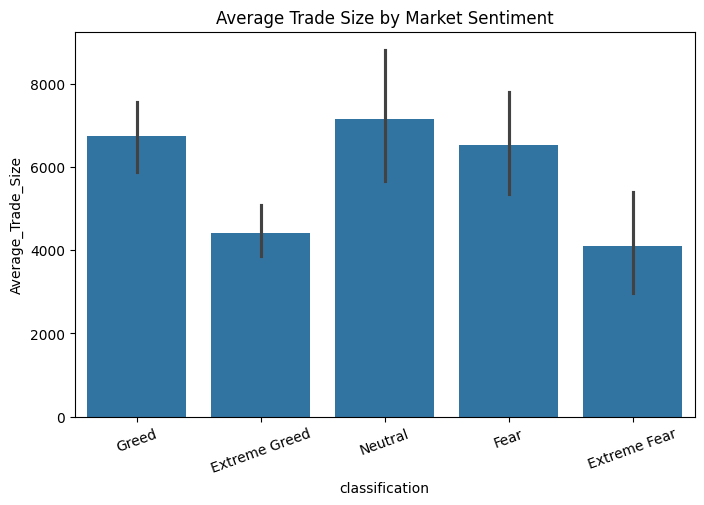

In [77]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=behaviour_analysis,
    x="classification",
    y="Average_Trade_Size",
    estimator="mean"
)

plt.title("Average Trade Size by Market Sentiment")
plt.xticks(rotation=20)
plt.show()

In [ ]:

# Trades per Trader

trader_frequency = (
    trader.groupby("Account")
    .agg(
        Total_Trades=("Trade ID", "count"),
        Total_PnL=("Closed PnL", "sum")
    )
    .reset_index()
)

trader_frequency.head()

,Account,Total_Trades,Total_PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05


In [79]:
median_trades = trader_frequency["Total_Trades"].median()

trader_frequency["Trader_Type"] = np.where(
    trader_frequency["Total_Trades"] >= median_trades,
    "Frequent",
    "Infrequent"
)

trader_frequency.head()

,Account,Total_Trades,Total_PnL,Trader_Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,Infrequent


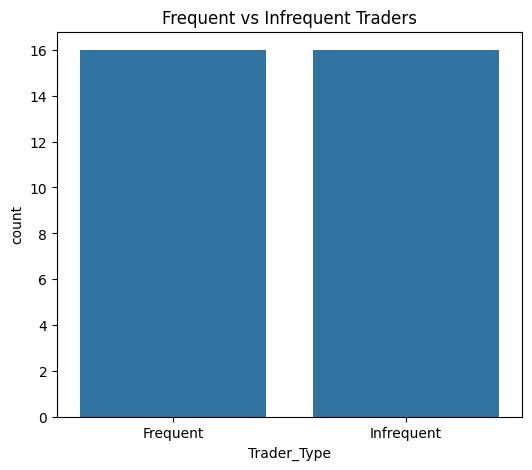

In [80]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=trader_frequency,
    x="Trader_Type"
)

plt.title("Frequent vs Infrequent Traders")
plt.show()

In [81]:
trader_frequency["Performance"] = np.where(
    trader_frequency["Total_PnL"] > 0,
    "Winner",
    "Loser"
)

trader_frequency.head()

,Account,Total_Trades,Total_PnL,Trader_Type,Performance
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,Frequent,Winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,Frequent,Winner
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,Frequent,Loser
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,Frequent,Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,Infrequent,Winner


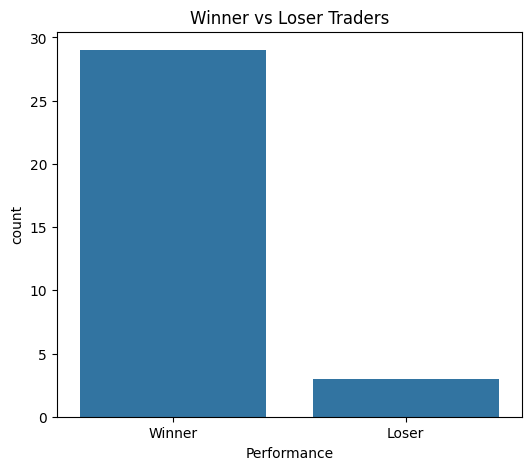

In [82]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=trader_frequency,
    x="Performance"
)

plt.title("Winner vs Loser Traders")
plt.show()

In [83]:
trade_size = (
    trader.groupby("Account")
    .agg(
        Average_Trade_Size=("Size USD", "mean")
    )
    .reset_index()
)

median_size = trade_size["Average_Trade_Size"].median()

trade_size["Trade_Size_Group"] = np.where(
    trade_size["Average_Trade_Size"] >= median_size,
    "High Value",
    "Low Value"
)

trade_size.head()

,Account,Average_Trade_Size,Trade_Size_Group
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734,High Value
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327,Low Value
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898,High Value
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933,Low Value
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782,Low Value


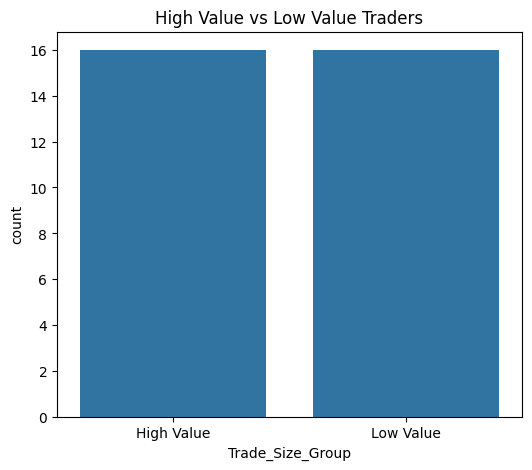

In [84]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=trade_size,
    x="Trade_Size_Group"
)

plt.title("High Value vs Low Value Traders")
plt.show()